In [ ]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

In [2]:
PANEL_FILE = "transaction_panel_v6_clean.xlsx"
 
L = 7 # distributed-lag window in days
 
ENTITY = "asa_id"
DATE   = "date"
 
X1 = [
    "delta_vix_z",
    "delta_dgs10_z",
    "delta_dgs1mo_z",
    "ads_z",
    "eth_return_z",
    "vnq_return_z",
    "mortgage_ret_z",
    "eth_shock",
]
 
df = pd.read_excel(PANEL_FILE)
df[DATE] = pd.to_datetime(df[DATE])
df = df.sort_values([ENTITY, DATE])
print(f"Loaded: {df.shape[0]:,} rows, {df[ENTITY].nunique()} entities")

Loaded: 64,194 rows, 192 entities


# Log Net Flows 

In [3]:
Y = "log_net_flow"

print("=" * 65)
print("  Model 1: All Variables")
print("=" * 65)
 
data_m1 = (
    df[[ENTITY, DATE, Y] + X1]
    .dropna()
    .set_index([ENTITY, DATE])
)
print(f"N obs: {len(data_m1):,}  |  N entities: {data_m1.index.get_level_values(0).nunique()}\n")
 
m1   = PanelOLS(data_m1[Y], data_m1[X1], entity_effects=True, time_effects=False)
res1 = m1.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res1.summary)
 
print("=" * 65)
print("  Model 1b: All Variables (Driscoll-Kraay)")
print("=" * 65)
 
m1b   = PanelOLS(data_m1[Y], data_m1[X1], entity_effects=True, time_effects=False)
res1b = m1b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res1b.summary)

  Model 1: All Variables
N obs: 64,194  |  N entities: 192

                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):              0.0066
No. Observations:               64194   R-squared (Within):               0.0016
Date:                Wed, May 27 2026   R-squared (Overall):              0.0023
Time:                        20:57:47   Log-likelihood                -1.131e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      12.571
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.34   Distribution:                 F(8,63994)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-statist

In [4]:
print("=" * 65)
print(f"  Model 2: Distributed-Lag FE (L={L}) — clustered (entity + time)")
print("=" * 65)
 

df_dl  = df[[ENTITY, DATE, Y] + X1].dropna().copy()
 
date_x = (
    df_dl[[DATE] + X1]
    .drop_duplicates(subset=DATE)
    .sort_values(DATE)
    .reset_index(drop=True)
    .copy()
)
 
X2 = []
for var in X1:
    for lag in range(L + 1):
        lag_name = f"{var}_lag{lag}"
        date_x[lag_name] = date_x[var].shift(lag)
        X2.append(lag_name)
 
data_dl = (
    df_dl[[ENTITY, DATE, Y]]
    .merge(date_x[[DATE] + X2], on=DATE, how="left")
    .dropna(subset=[Y] + X2)
    .set_index([ENTITY, DATE])
    .sort_index()
)
print(f"N obs: {len(data_dl):,}  |  N entities: {data_dl.index.get_level_values(0).nunique()}\n")
 
m2   = PanelOLS(data_dl[Y], data_dl[X2], entity_effects=True, time_effects=False)
res2 = m2.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res2.summary)
 
print("=" * 65)
print(f"  Model 2b: Distributed-Lag FE (L={L}) — Driscoll-Kraay (Bartlett, bw=7)")
print("=" * 65)
 
m2b   = PanelOLS(data_dl[Y], data_dl[X2], entity_effects=True, time_effects=False)
res2b = m2b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res2b.summary)

  Model 2: Distributed-Lag FE (L=7) — clustered (entity + time)
N obs: 64,187  |  N entities: 192

                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0071
Estimator:                   PanelOLS   R-squared (Between):              0.0094
No. Observations:               64187   R-squared (Within):               0.0071
Date:                Wed, May 27 2026   R-squared (Overall):              0.0096
Time:                        20:57:49   Log-likelihood                -1.129e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.1311
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.31   Distribution:                F(64,63931)
Min Obs:                       5.0000                                           
Max Obs:  

In [5]:
X3 = [
    "delta_vix_z",
    "delta_dgs1mo_z",
    "ads_z",
    "eth_return_z",
    "vnq_return_z",
    "mortgage_ret_z",
    "eth_shock",
]

print("=" * 65)
print("  Model 3: 10 year treasury excluded")
print("=" * 65)
 
data_m3 = (
    df[[ENTITY, DATE, Y] + X3]
    .dropna()
    .set_index([ENTITY, DATE])
)
 
m3   = PanelOLS(data_m3[Y], data_m3[X3], entity_effects=True, time_effects=False)
res3 = m3.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res3.summary)
 
print("=" * 65)
print("  Model 3b: 10 year treasury excluded (Driscoll-Kraay)")
print("=" * 65)
 
m3b   = PanelOLS(data_m3[Y], data_m3[X3], entity_effects=True, time_effects=False)
res3b = m3b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res3b.summary)

  Model 3: 10 year treasury excluded
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):              0.0066
No. Observations:               64194   R-squared (Within):               0.0016
Date:                Wed, May 27 2026   R-squared (Overall):              0.0023
Time:                        20:57:51   Log-likelihood                -1.131e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      14.367
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.34   Distribution:                 F(7,63995)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-statistic (robust):           

In [6]:
print("=" * 65)
print(f"  Model 4: Distributed-Lag FE (L={L}) — clustered (entity + time)")
print("=" * 65)

df_dl  = df[[ENTITY, DATE, Y] + X3].dropna().copy()
 
date_x = (
    df_dl[[DATE] + X3]
    .drop_duplicates(subset=DATE)
    .sort_values(DATE)
    .reset_index(drop=True)
    .copy()
)
 
X4 = []
for var in X3:
    for lag in range(L + 1):
        lag_name = f"{var}_lag{lag}"
        date_x[lag_name] = date_x[var].shift(lag)
        X4.append(lag_name)
 
data_dl = (
    df_dl[[ENTITY, DATE, Y]]
    .merge(date_x[[DATE] + X4], on=DATE, how="left")
    .dropna(subset=[Y] + X4)
    .set_index([ENTITY, DATE])
    .sort_index()
)
 
m4   = PanelOLS(data_dl[Y], data_dl[X4], entity_effects=True, time_effects=False)
res4 = m4.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res4.summary)
 
print("=" * 65)
print(f"  Model 4b: Distributed-Lag FE (L={L}) — Driscoll-Kraay (Bartlett, bw=7)")
print("=" * 65)
 
m4b   = PanelOLS(data_dl[Y], data_dl[X4], entity_effects=True, time_effects=False)
res4b = m4b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res4b.summary)

  Model 4: Distributed-Lag FE (L=7) — clustered (entity + time)
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0069
Estimator:                   PanelOLS   R-squared (Between):              0.0091
No. Observations:               64187   R-squared (Within):               0.0069
Date:                Wed, May 27 2026   R-squared (Overall):              0.0094
Time:                        20:57:52   Log-likelihood                -1.129e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.9543
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.31   Distribution:                F(56,63939)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-sta

In [7]:
X5 = [
    "delta_vix_z",
    "delta_dgs1mo_z",
    "ads_z",
    "eth_return_z",
    "mortgage_ret_z",
    "eth_shock",
]

print("=" * 65)
print("  Model 5: 10 year treasury + VNQ excluded")
print("=" * 65)
 
data_m5 = (
    df[[ENTITY, DATE, Y] + X5]
    .dropna()
    .set_index([ENTITY, DATE])
)
 
m5   = PanelOLS(data_m3[Y], data_m3[X5], entity_effects=True, time_effects=False)
res5 = m5.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res5.summary)
 
print("=" * 65)
print("  Model 5b: 10 year treasury + VNQ excluded (Driscoll-Kraay)")
print("=" * 65)
 
m5b   = PanelOLS(data_m5[Y], data_m5[X5], entity_effects=True, time_effects=False)
res5b = m5b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res5b.summary)

  Model 5: 10 year treasury + VNQ excluded
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):              0.0066
No. Observations:               64194   R-squared (Within):               0.0016
Date:                Wed, May 27 2026   R-squared (Overall):              0.0023
Time:                        20:57:54   Log-likelihood                -1.131e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      16.757
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.34   Distribution:                 F(6,63996)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-statistic (robust):     

In [8]:
print("=" * 65)
print(f"  Model 6: Distributed-Lag FE (L={L}) — clustered (entity + time)")
print("=" * 65)

df_dl  = df[[ENTITY, DATE, Y] + X5].dropna().copy()
 
date_x = (
    df_dl[[DATE] + X5]
    .drop_duplicates(subset=DATE)
    .sort_values(DATE)
    .reset_index(drop=True)
    .copy()
)
 
X6 = []
for var in X5:
    for lag in range(L + 1):
        lag_name = f"{var}_lag{lag}"
        date_x[lag_name] = date_x[var].shift(lag)
        X6.append(lag_name)
 
data_dl = (
    df_dl[[ENTITY, DATE, Y]]
    .merge(date_x[[DATE] + X6], on=DATE, how="left")
    .dropna(subset=[Y] + X6)
    .set_index([ENTITY, DATE])
    .sort_index()
)
 
m6   = PanelOLS(data_dl[Y], data_dl[X6], entity_effects=True, time_effects=False)
res6 = m6.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res6.summary)
 
print("=" * 65)
print(f"  Model 6b: Distributed-Lag FE (L={L}) — Driscoll-Kraay (Bartlett, bw=7)")
print("=" * 65)
 
m6b   = PanelOLS(data_dl[Y], data_dl[X6], entity_effects=True, time_effects=False)
res6b = m6b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res6b.summary)

  Model 6: Distributed-Lag FE (L=7) — clustered (entity + time)
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0068
Estimator:                   PanelOLS   R-squared (Between):              0.0102
No. Observations:               64187   R-squared (Within):               0.0068
Date:                Wed, May 27 2026   R-squared (Overall):              0.0093
Time:                        20:57:55   Log-likelihood                -1.129e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.1528
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.31   Distribution:                F(48,63947)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-sta

In [9]:
X7 = [
    "delta_dgs1mo_z",
    "ads_z",
    "eth_return_z",
    "mortgage_ret_z",
    "eth_shock",
]

print("=" * 65)
print("  Model 7: 10 year treasury, VNQ + VIX excluded")
print("=" * 65)
 
data_m7 = (
    df[[ENTITY, DATE, Y] + X7]
    .dropna()
    .set_index([ENTITY, DATE])
)
 
m7   = PanelOLS(data_m7[Y], data_m7[X7], entity_effects=True, time_effects=False)
res7 = m7.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res7.summary)
 
print("=" * 65)
print("  Model 7b: 10 year treasury, VNQ + VIX excluded (Driscoll-Kraay)")
print("=" * 65)
 
m7b   = PanelOLS(data_m7[Y], data_m7[X7], entity_effects=True, time_effects=False)
res7b = m7b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res7b.summary)

  Model 7: 10 year treasury, VNQ + VIX excluded
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):              0.0069
No. Observations:               64194   R-squared (Within):               0.0016
Date:                Wed, May 27 2026   R-squared (Overall):              0.0023
Time:                        20:57:57   Log-likelihood                -1.131e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      19.954
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.34   Distribution:                 F(5,63997)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-statistic (robust):

In [10]:
print("=" * 65)
print(f"  Model 8: Distributed-Lag FE (L={L}) — clustered (entity + time)")
print("=" * 65)

df_dl  = df[[ENTITY, DATE, Y] + X7].dropna().copy()
 
date_x = (
    df_dl[[DATE] + X7]
    .drop_duplicates(subset=DATE)
    .sort_values(DATE)
    .reset_index(drop=True)
    .copy()
)
 
X8 = []
for var in X7:
    for lag in range(L + 1):
        lag_name = f"{var}_lag{lag}"
        date_x[lag_name] = date_x[var].shift(lag)
        X8.append(lag_name)
 
data_dl = (
    df_dl[[ENTITY, DATE, Y]]
    .merge(date_x[[DATE] + X8], on=DATE, how="left")
    .dropna(subset=[Y] + X8)
    .set_index([ENTITY, DATE])
    .sort_index()
)
 
m8   = PanelOLS(data_dl[Y], data_dl[X8], entity_effects=True, time_effects=False)
res8 = m8.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res8.summary)
 
print("=" * 65)
print(f"  Model 8b: Distributed-Lag FE (L={L}) — Driscoll-Kraay (Bartlett, bw=7)")
print("=" * 65)
 
m8b   = PanelOLS(data_dl[Y], data_dl[X8], entity_effects=True, time_effects=False)
res8b = m8b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res8b.summary)

  Model 8: Distributed-Lag FE (L=7) — clustered (entity + time)
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0065
Estimator:                   PanelOLS   R-squared (Between):              0.0091
No. Observations:               64187   R-squared (Within):               0.0065
Date:                Wed, May 27 2026   R-squared (Overall):              0.0090
Time:                        20:57:58   Log-likelihood                -1.129e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.428
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.31   Distribution:                F(40,63955)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-sta

In [11]:
X9 = [
    "delta_dgs1mo_z",
    "ads_z",
    "eth_return_z",
    "eth_shock",
]

print("=" * 65)
print("  Model 9: 10 year treasury, VNQ, VIX + Mortgage Index returns excluded")
print("=" * 65)
 
data_m9 = (
    df[[ENTITY, DATE, Y] + X9]
    .dropna()
    .set_index([ENTITY, DATE])
)
 
m9   = PanelOLS(data_m9[Y], data_m9[X9], entity_effects=True, time_effects=False)
res9 = m9.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res9.summary)
 
print("=" * 65)
print("  Model 9b: 10 year treasury, VNQ, VIX + Mortgage Index returns excluded (Driscoll-Kraay)")
print("=" * 65)
 
m9b   = PanelOLS(data_m9[Y], data_m9[X9], entity_effects=True, time_effects=False)
res9b = m9b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res9b.summary)

  Model 9: 10 year treasury, VNQ, VIX + Mortgage Index returns excluded
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0015
Estimator:                   PanelOLS   R-squared (Between):              0.0067
No. Observations:               64194   R-squared (Within):               0.0015
Date:                Wed, May 27 2026   R-squared (Overall):              0.0022
Time:                        20:57:59   Log-likelihood                -1.131e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      24.766
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.34   Distribution:                 F(4,63998)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0

In [12]:
print("=" * 65)
print(f"  Model 10: Distributed-Lag FE (L={L}) — clustered (entity + time)")
print("=" * 65)

df_dl  = df[[ENTITY, DATE, Y] + X9].dropna().copy()
 
date_x = (
    df_dl[[DATE] + X9]
    .drop_duplicates(subset=DATE)
    .sort_values(DATE)
    .reset_index(drop=True)
    .copy()
)
 
X10 = []
for var in X9:
    for lag in range(L + 1):
        lag_name = f"{var}_lag{lag}"
        date_x[lag_name] = date_x[var].shift(lag)
        X10.append(lag_name)
 
data_dl = (
    df_dl[[ENTITY, DATE, Y]]
    .merge(date_x[[DATE] + X10], on=DATE, how="left")
    .dropna(subset=[Y] + X10)
    .set_index([ENTITY, DATE])
    .sort_index()
)
 
m10   = PanelOLS(data_dl[Y], data_dl[X10], entity_effects=True, time_effects=False)
res10 = m10.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res10.summary)
 
print("=" * 65)
print(f"  Model 10b: Distributed-Lag FE (L={L}) — Driscoll-Kraay (Bartlett, bw=7)")
print("=" * 65)
 
m10b   = PanelOLS(data_dl[Y], data_dl[X10], entity_effects=True, time_effects=False)
res10b = m10b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res10b.summary)

  Model 10: Distributed-Lag FE (L=7) — clustered (entity + time)
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0064
Estimator:                   PanelOLS   R-squared (Between):              0.0088
No. Observations:               64187   R-squared (Within):               0.0064
Date:                Wed, May 27 2026   R-squared (Overall):              0.0089
Time:                        20:58:00   Log-likelihood                -1.129e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      12.798
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.31   Distribution:                F(32,63963)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-st

In [13]:
X11 = [
    "delta_dgs1mo_z",
    "ads_z",
    "eth_shock",
]

print("=" * 65)
print("  Model 11: 10 year treasury, VNQ, VIX, Mortgage Index returns + ETH returns excluded")
print("=" * 65)
 
data_m11 = (
    df[[ENTITY, DATE, Y] + X11]
    .dropna()
    .set_index([ENTITY, DATE])
)
 
m11   = PanelOLS(data_m11[Y], data_m11[X11], entity_effects=True, time_effects=False)
res11 = m11.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res11.summary)
 
print("=" * 65)
print("  Model 11b: 10 year treasury, VNQ, VIX, Mortgage Index returns + ETH returns excluded (Driscoll-Kraay)")
print("=" * 65)
 
m11b   = PanelOLS(data_m11[Y], data_m11[X11], entity_effects=True, time_effects=False)
res11b = m11b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res11b.summary)

  Model 11: 10 year treasury, VNQ, VIX, Mortgage Index returns + ETH returns excluded
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0015
Estimator:                   PanelOLS   R-squared (Between):              0.0053
No. Observations:               64194   R-squared (Within):               0.0015
Date:                Wed, May 27 2026   R-squared (Overall):              0.0022
Time:                        20:58:02   Log-likelihood                -1.131e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      32.233
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.34   Distribution:                 F(3,63999)
Min Obs:                       5.0000                                           
Max Obs:               

In [14]:
print("=" * 65)
print(f"  Model 12: Distributed-Lag FE (L={L}) — clustered (entity + time)")
print("=" * 65)

df_dl  = df[[ENTITY, DATE, Y] + X11].dropna().copy()
 
date_x = (
    df_dl[[DATE] + X11]
    .drop_duplicates(subset=DATE)
    .sort_values(DATE)
    .reset_index(drop=True)
    .copy()
)
 
X12 = []
for var in X11:
    for lag in range(L + 1):
        lag_name = f"{var}_lag{lag}"
        date_x[lag_name] = date_x[var].shift(lag)
        X12.append(lag_name)
 
data_dl = (
    df_dl[[ENTITY, DATE, Y]]
    .merge(date_x[[DATE] + X12], on=DATE, how="left")
    .dropna(subset=[Y] + X12)
    .set_index([ENTITY, DATE])
    .sort_index()
)
 
m12   = PanelOLS(data_dl[Y], data_dl[X12], entity_effects=True, time_effects=False)
res12 = m12.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res12.summary)
 
print("=" * 65)
print(f"  Model 12b: Distributed-Lag FE (L={L}) — Driscoll-Kraay (Bartlett, bw=7)")
print("=" * 65)
 
m12b   = PanelOLS(data_dl[Y], data_dl[X12], entity_effects=True, time_effects=False)
res12b = m12b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res12b.summary)

  Model 12: Distributed-Lag FE (L=7) — clustered (entity + time)
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0053
Estimator:                   PanelOLS   R-squared (Between):              0.0120
No. Observations:               64187   R-squared (Within):               0.0053
Date:                Wed, May 27 2026   R-squared (Overall):              0.0073
Time:                        20:58:02   Log-likelihood                 -1.13e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      14.310
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.31   Distribution:                F(24,63971)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-st

In [15]:
X13 = [
    "delta_dgs1mo_z",
    "ads_z"
]

print("=" * 65)
print("  Model 13: 10 year treasury, VNQ, VIX, Mortgage Index returns, ETH returns and shocks excluded")
print("=" * 65)
 
data_m13 = (
    df[[ENTITY, DATE, Y] + X13]
    .dropna()
    .set_index([ENTITY, DATE])
)
 
m13   = PanelOLS(data_m11[Y], data_m11[X13], entity_effects=True, time_effects=False)
res13 = m13.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res13.summary)
 
print("=" * 65)
print("  Model 13b: 10 year treasury, VNQ, VIX, Mortgage Index return, ETH returns and shocks excluded (Driscoll-Kraay)")
print("=" * 65)
 
m13b   = PanelOLS(data_m13[Y], data_m13[X13], entity_effects=True, time_effects=False)
res13b = m13b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res13b.summary)

  Model 13: 10 year treasury, VNQ, VIX, Mortgage Index returns, ETH returns and shocks excluded
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0014
Estimator:                   PanelOLS   R-squared (Between):              0.0004
No. Observations:               64194   R-squared (Within):               0.0014
Date:                Wed, May 27 2026   R-squared (Overall):              0.0014
Time:                        20:58:03   Log-likelihood                -1.131e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      43.361
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.34   Distribution:                 F(2,64000)
Min Obs:                       5.0000                                           
Max Obs:     

In [16]:
print("=" * 65)
print(f"  Model 14: Distributed-Lag FE (L={L}) — clustered (entity + time)")
print("=" * 65)

df_dl  = df[[ENTITY, DATE, Y] + X13].dropna().copy()
 
date_x = (
    df_dl[[DATE] + X13]
    .drop_duplicates(subset=DATE)
    .sort_values(DATE)
    .reset_index(drop=True)
    .copy()
)
 
X14 = []
for var in X13:
    for lag in range(L + 1):
        lag_name = f"{var}_lag{lag}"
        date_x[lag_name] = date_x[var].shift(lag)
        X14.append(lag_name)
 
data_dl = (
    df_dl[[ENTITY, DATE, Y]]
    .merge(date_x[[DATE] + X14], on=DATE, how="left")
    .dropna(subset=[Y] + X14)
    .set_index([ENTITY, DATE])
    .sort_index()
)
 
m14   = PanelOLS(data_dl[Y], data_dl[X14], entity_effects=True, time_effects=False)
res14 = m14.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res14.summary)
 
print("=" * 65)
print(f"  Model 14b: Distributed-Lag FE (L={L}) — Driscoll-Kraay (Bartlett, bw=7)")
print("=" * 65)
 
m14b   = PanelOLS(data_dl[Y], data_dl[X14], entity_effects=True, time_effects=False)
res14b = m14b.fit(cov_type="kernel", kernel="bartlett", bandwidth=7)
print(res14b.summary)

  Model 14: Distributed-Lag FE (L=7) — clustered (entity + time)
                          PanelOLS Estimation Summary                           
Dep. Variable:           log_net_flow   R-squared:                        0.0042
Estimator:                   PanelOLS   R-squared (Between):             -0.0010
No. Observations:               64187   R-squared (Within):               0.0042
Date:                Wed, May 27 2026   R-squared (Overall):              0.0041
Time:                        20:58:04   Log-likelihood                 -1.13e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      16.694
Entities:                         192   P-value                           0.0000
Avg Obs:                       334.31   Distribution:                F(16,63979)
Min Obs:                       5.0000                                           
Max Obs:                       1137.0   F-st

1 month treasury yields and ADS are significant

In [19]:
from scipy import stats
 
def cumulative_beta_summary(res, x_vars, label, L=7):
    rows = []
    for var in x_vars:
        lag_names = [f"{var}_lag{l}" for l in range(L + 1)]
        lag_names = [ln for ln in lag_names if ln in res.params.index]
        if not lag_names:
            continue
 
        beta_sum   = res.params[lag_names].sum()
        cov_sub    = res.cov.loc[lag_names, lag_names]
        se_sum     = np.sqrt(cov_sub.values.sum())
        t_stat     = beta_sum / se_sum
        p_value    = 2 * (1 - stats.norm.cdf(abs(t_stat)))
        pct_effect = 100 * (np.exp(beta_sum) - 1)
        sig        = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else ""
 
        rows.append({
            "variable":   var,
            "cumul_beta":   round(beta_sum,   4),
            "std_err":    round(se_sum,     4),
            "t_stat":     round(t_stat,     3),
            "p_value":    round(p_value,    4),
            "sig":        sig,
            "pct_effect": round(pct_effect, 2),
        })
 
    df_out = pd.DataFrame(rows)
    print(f"=== Cumulative IRF — {label} ===")
    print(f"(sum of lag0..lag{L} per variable, SE via delta method)")
    print(df_out.to_string(index=False))
    print()
    return df_out
 
 
# Models 2 / 2b 
cumulative_beta_summary(res2,  X1, "Model 2  — Clustered")
cumulative_beta_summary(res2b, X1, "Model 2b — Driscoll-Kraay")
 
# Models 4 / 4b 
cumulative_beta_summary(res4,  X3, "Model 4  — Clustered")
cumulative_beta_summary(res4b, X3, "Model 4b — Driscoll-Kraay")
 
# Models 6 / 6b
cumulative_beta_summary(res6,  X5, "Model 6  — Clustered")
cumulative_beta_summary(res6b, X5, "Model 6b — Driscoll-Kraay")
 
# Models 8 / 8b 
cumulative_beta_summary(res8,  X7, "Model 8  — Clustered")
cumulative_beta_summary(res8b, X7, "Model 8b — Driscoll-Kraay")
 
# Models 10 / 10b  
cumulative_beta_summary(res10,  X9, "Model 10  — Clustered")
cumulative_beta_summary(res10b, X9, "Model 10b — Driscoll-Kraay")
 
# Models 12 / 12b 
cumulative_beta_summary(res12,  X11, "Model 12  — Clustered")
cumulative_beta_summary(res12b, X11, "Model 12b — Driscoll-Kraay")

=== Cumulative IRF — Model 2  — Clustered ===
(sum of lag0..lag7 per variable, SE via delta method)
      variable  cumul_beta  std_err  t_stat  p_value sig  pct_effect
   delta_vix_z      0.0426   0.0356   1.196   0.2317            4.35
 delta_dgs10_z      0.0269   0.0260   1.035   0.3009            2.73
delta_dgs1mo_z      0.1238   0.0325   3.807   0.0001 ***       13.18
         ads_z      0.0674   0.0242   2.784   0.0054 ***        6.97
  eth_return_z      0.0864   0.0469   1.842   0.0654   *        9.02
  vnq_return_z      0.0075   0.0521   0.143   0.8861            0.75
mortgage_ret_z      0.0355   0.0513   0.692   0.4890            3.61
     eth_shock      0.2566   0.0757   3.389   0.0007 ***       29.25

=== Cumulative IRF — Model 2b — Driscoll-Kraay ===
(sum of lag0..lag7 per variable, SE via delta method)
      variable  cumul_beta  std_err  t_stat  p_value sig  pct_effect
   delta_vix_z      0.0426   0.0433   0.984   0.3252            4.35
 delta_dgs10_z      0.0269   0.0308

,variable,cumul_beta,std_err,t_stat,p_value,sig,pct_effect
0,delta_dgs1mo_z,0.1270,0.0475,2.675,0.0075,***,13.54
1,ads_z,0.0699,0.0240,2.915,0.0036,***,7.24
2,eth_shock,0.1620,0.0630,2.571,0.0101,**,17.59


Loaded: 64,194 rows, 192 entities


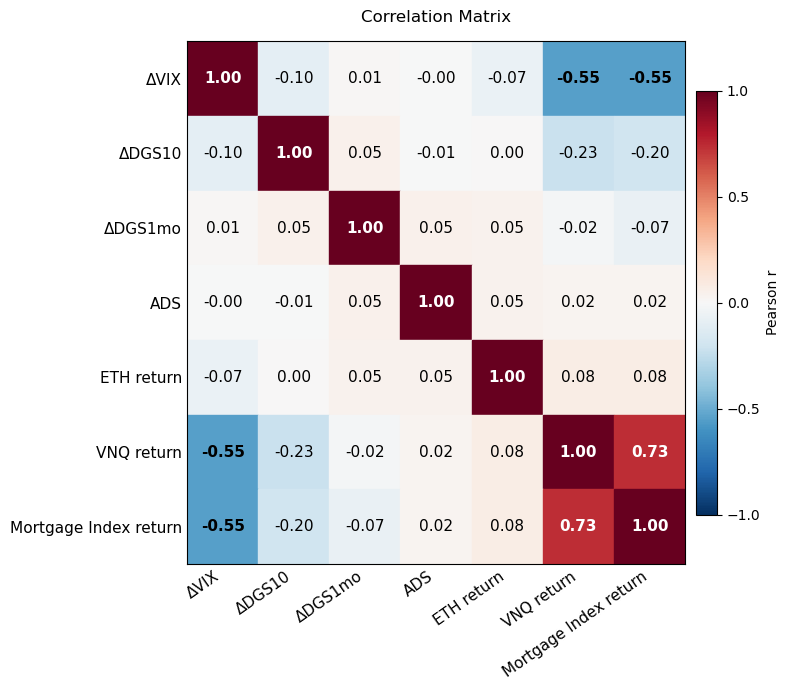

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

PANEL_FILE = "transaction_panel_v6_clean.xlsx"
 
L = 7               
 
ENTITY = "asa_id"
DATE   = "date"
 
X_BASE = [
    "delta_vix_z",
    "delta_dgs10_z",
    "delta_dgs1mo_z",
    "ads_z",
    "eth_return_z",
    "vnq_return_z",
    "mortgage_ret_z",
    "eth_shock",
]
 

df = pd.read_excel(PANEL_FILE)
df[DATE] = pd.to_datetime(df[DATE])
df = df.sort_values([ENTITY, DATE])
print(f"Loaded: {df.shape[0]:,} rows, {df[ENTITY].nunique()} entities")

VARS   = ["delta_vix", "delta_dgs10", "delta_dgs1mo", "ads", "eth_return", "vnq_return", "mortgage_ret"]
LABELS = ["ΔVIX", "ΔDGS10", "ΔDGS1mo", "ADS", "ETH return", "VNQ return", "Mortgage Index return"]
 
data_corr   = df[VARS].dropna()
corr   = data_corr.corr()
n_vars = len(VARS)
 
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
 
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
 
for i in range(n_vars):
    for j in range(n_vars):
        val   = corr.iloc[i, j]
        color = cmap(norm(val))
        ax.add_patch(plt.Rectangle((j, n_vars - 1 - i), 1, 1, color=color))
        brightness = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
        txt_color  = "white" if brightness < 0.55 else "black"
        ax.text(j + 0.5, n_vars - 0.5 - i, f"{val:.2f}",
                ha="center", va="center", fontsize=11,
                color=txt_color,
                fontweight="bold" if abs(val) > 0.3 else "normal")
 
ax.set_xlim(0, n_vars)
ax.set_ylim(0, n_vars)
ax.set_xticks([i + 0.5 for i in range(n_vars)])
ax.set_yticks([i + 0.5 for i in range(n_vars)])
ax.set_xticklabels(LABELS, fontsize=11)
plt.xticks(rotation=35, ha='right')
ax.set_yticklabels(LABELS[::-1], fontsize=11)
ax.tick_params(length=0)
 
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Pearson r", fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
 
ax.set_title(f"Correlation Matrix",
             fontsize=12, pad=14)
 
plt.tight_layout()